In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os
import sys
import importlib
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
import spk_feat_cluster_comp_analysis
importlib.reload(spk_feat_cluster_comp_analysis)
from spk_feat_cluster_comp_analysis import (
    compile_experiment_results,
    plot_aggregated_spike_feat,
    plot_temporal_structure,
    analyze_cross_correlations,
    plot_sig_feat_pairs,
    plot_feature_depth_distribution,
    stat_test_depth_stratification,
)
import config

CLUSTER_PKL_DIR = config.SPE1_PICKLE_ROOT + '/cluster_pickles/'

In [2]:
df_master = compile_experiment_results(CLUSTER_PKL_DIR)

In [ ]:
# Panel A: feature prevalence and waveform separation
# Match exclusions from supp_cluster_distributions: skip timing + exp_const + degenerate cells
_SKIP = {'spk_times_ms', 'spk_times_idx', 'exp_const'}
_CELLS_EXCLUDE = {'peak_width': ['c15'], 'inflection_time': ['c7']}

df_wf = df_master[~df_master['spike_feature'].isin(_SKIP)].copy()
for feat, excl in _CELLS_EXCLUDE.items():
    df_wf = df_wf[~((df_wf['spike_feature'] == feat) & (df_wf['cell_id'].isin(excl)))]

plot_aggregated_spike_feat(df_wf)
plt.show()

/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:1929: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='temporal_rho', y='spike_feature', order=feat_order,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:1931: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_plot, x='temporal_rho', y='spike_feature', order=feat_order,


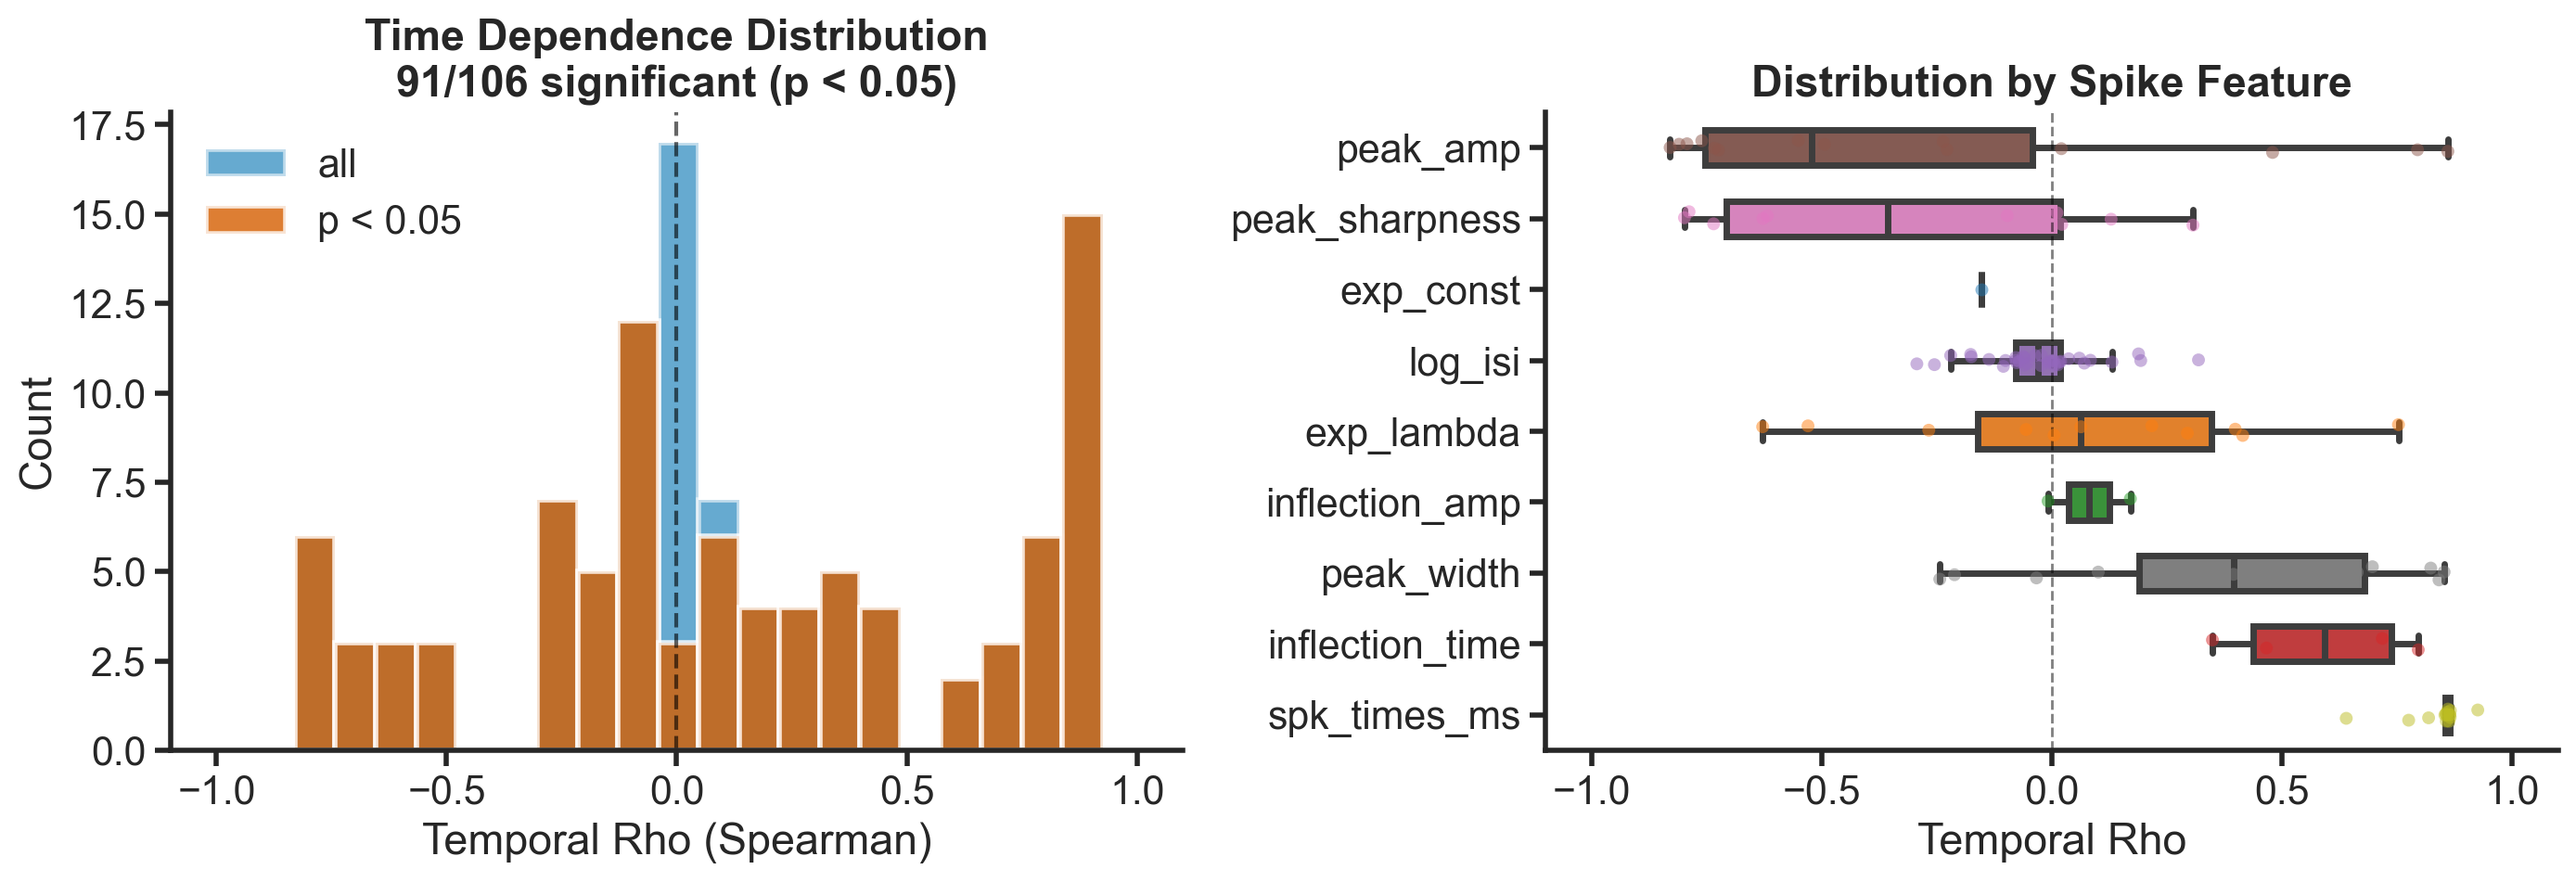


Time dependence summary (p < 0.05):
  Significant: 91 / 106 cell-feature groups (85.8%)
  Mean |rho|: 0.391

Significant groups:
cell_id   spike_feature  temporal_rho temporal_p
    c32        peak_amp        -0.829    <0.0001
    c41        peak_amp        -0.810    <0.0001
     c7  peak_sharpness        -0.798    <0.0001
     c1        peak_amp        -0.793    <0.0001
    c32  peak_sharpness        -0.788    <0.0001
    c42        peak_amp        -0.761    <0.0001
    c22  peak_sharpness        -0.735    <0.0001
    c10        peak_amp        -0.733    <0.0001
     c3        peak_amp        -0.724    <0.0001
     c6      exp_lambda        -0.628    <0.0001
     c1  peak_sharpness        -0.628    <0.0001
    c21  peak_sharpness        -0.618    <0.0001
    c44        peak_amp        -0.551    <0.0001
     c1      exp_lambda        -0.530    <0.0001
    c33        peak_amp        -0.494    <0.0001
     c4         log_isi        -0.293    <0.0001
    c19      exp_lambda        -0.267

In [4]:
# Panel B: temporal structure of cluster membership per feature
df_plot = df_master[df_master['spike_feature'] != 'spk_times_idx']
plot_temporal_structure(df_plot)
plt.show()

In [ ]:
# Panel C: recording/cell property associations with waveform cluster separation
_SKIP = {'spk_times_ms', 'spk_times_idx', 'exp_const'}
_CELLS_EXCLUDE = {'peak_width': ['c15'], 'inflection_time': ['c7']}

df_wf = df_master[~df_master['spike_feature'].isin(_SKIP)].copy()
for feat, excl in _CELLS_EXCLUDE.items():
    df_wf = df_wf[~((df_wf['spike_feature'] == feat) & (df_wf['cell_id'].isin(excl)))]

_df_num = df_wf.copy()
_df_num['num_clusters'] = pd.to_numeric(_df_num['num_clusters'], errors='coerce')
_n_clust = (_df_num[_df_num['num_clusters'] >= 2]
            .groupby('cell_id')['spike_feature'].nunique()
            .rename('n_clustering_features'))
df_wf = df_wf.join(_n_clust, on='cell_id')

sig_meta_clust_feats = analyze_cross_correlations(df_wf)
plot_sig_feat_pairs(df_wf, sig_meta_clust_feats)
plt.show()

**Supplementary Figure X. Characterization of spike waveform cluster properties.**

**(A)** Prevalence of clustering across cells for each spike waveform feature (fraction of cells showing multimodal clustering), with mean nRMSE and cosine similarity between clusters shown as measures of waveform separation.

**(B)** Temporal structure of cluster membership. Histogram shows the distribution of Spearman ρ between spike index (time within recording) and ordinal cluster label, across all (cell × feature) pairs. Colored distributions show ρ per spike waveform feature. High |ρ| indicates that cluster membership is systematically ordered over the recording duration.

**(C)** Significant associations between recording or cell properties and waveform separation between clusters (nRMSE, cosine similarity), assessed via Spearman correlation with BH-FDR correction across all tested pairs. Only significant associations shown.

**(D)** Cortical depth distribution of cells, split by which spike waveform feature exhibits clustering. No significant depth stratification was observed (Kruskal–Wallis), indicating that waveform feature variability is not organized by cortical layer.

In [ ]:
# Panel D: cortical depth distribution by spike feature
_SKIP = {'spk_times_ms', 'spk_times_idx', 'exp_const'}
_CELLS_EXCLUDE = {'peak_width': ['c15'], 'inflection_time': ['c7']}

df_wf = df_master[~df_master['spike_feature'].isin(_SKIP)].copy()
for feat, excl in _CELLS_EXCLUDE.items():
    df_wf = df_wf[~((df_wf['spike_feature'] == feat) & (df_wf['cell_id'].isin(excl)))]

plot_feature_depth_distribution(df_wf)
plt.show()
_ = stat_test_depth_stratification(df_wf)